In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Conectamos con la carpeta de códigos
sys.path.append('../codigos')

# Importamos la NUEVA función
from solvers import ftcs_2d_homogeneo

In [3]:
# 1. Parámetros físicos y numéricos
D = 1.0      
rho = 1.0    
nx, ny = 100, 100  
dx, dy = 0.2, 0.2
dt = 0.005         # Recordar el criterio de estabilidad más estricto en 2D
nt = 800           

# 2. Tablero inicial (Placa Petri vacía)
u_0 = np.zeros((nx, ny))

# 3. Semillero tumoral central (un cuadrado de células)
centro_x, centro_y = nx // 2, ny // 2
radio = 3
u_0[centro_x-radio : centro_x+radio, centro_y-radio : centro_y+radio] = 1.0

# 4. ¡Ejecutamos el motor 2D!
print("Calculando difusión 2D...")
u_final = ftcs_2d_homogeneo(D, rho, nx, ny, dx, dy, dt, nt, u_0)
print("¡Cálculo terminado!")

Calculando difusión 2D...
¡Cálculo terminado!


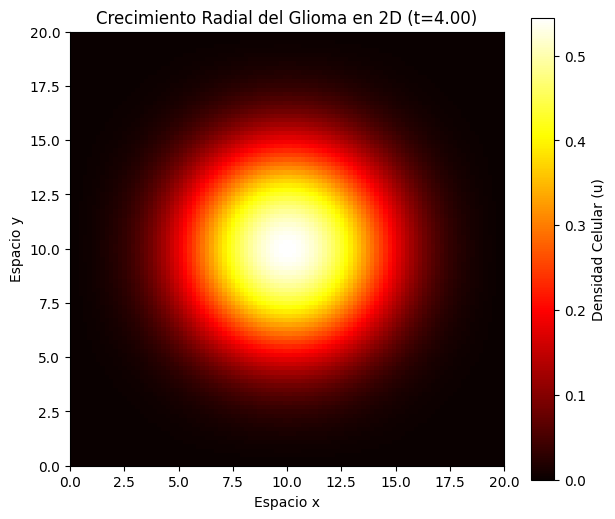

In [4]:
plt.figure(figsize=(7, 6))

# Usamos imshow para dibujar la matriz como imagen
imagen = plt.imshow(u_final, cmap='hot', origin='lower', extent=[0, nx*dx, 0, ny*dy])

plt.colorbar(imagen, label='Densidad Celular (u)')
plt.title(f'Crecimiento Radial del Glioma en 2D (t={nt*dt:.2f})')
plt.xlabel('Espacio x')
plt.ylabel('Espacio y')

plt.show()